Part B of Lab 2

In [71]:
import pandas as pd
import numpy as numpy
from matplotlib import pyplot as plt
import scipy.stats as stats
import seaborn as sns
from matplotlib import rcParams
from statsmodels.formula.api import ols
from sklearn.linear_model import LinearRegression

#used to split the test from train data
from sklearn.model_selection import train_test_split

#used to add a constant when using OLS model
import statsmodels.api as sm

In [72]:
df = pd.read_csv('M2 - Bikes - bikes.csv')
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 0:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 1:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 2:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 3:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 4:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [73]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [75]:
#check ros with null values
df[df.isnull().any(axis=1)]

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count


In [76]:
#check which columns have null values
df.isna().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

In [77]:
#getting rid of null values
newDf = df.fillna(0)
newDf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [78]:
newDf.isna().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

Preparing and then Seperating the data in test and train data for Linear Regression Model.

In [79]:
# Select temp as the predictor variable (X)
x = df[['temp']].values

# Dependent variable (y): count
y = df['count'].values

x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 1/3, random_state=5)

In [80]:
regressor= LinearRegression()
regressor.fit(x_train, y_train)

#Prediction of Test and Training set result
y_pred= regressor.predict(x_test)
y_train_pred= regressor.predict(x_train)

print("\ny_pred",y_pred)
print("x_pred",y_train_pred)





y_pred [247.22997475 307.44392647 149.38230321 ... 284.86369458 239.70323079
 171.9625351 ]
x_pred [187.01602303 232.17648682 171.9625351  ... 141.85555924 284.86369458
 284.86369458]


Summarizng the data using Linear Regression Model

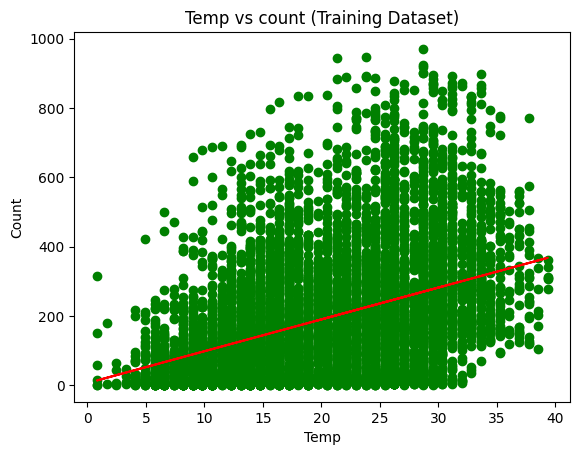

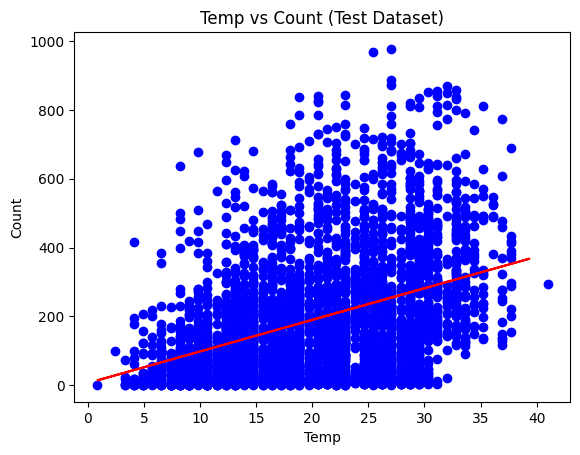

In [81]:
#visualizing the Training set results

plt.scatter(x_train, y_train, color="green")
plt.plot(x_train, y_train_pred, color="red")
plt.title("Temp vs count (Training Dataset)")
plt.xlabel("Temp")
plt.ylabel("Count")
plt.show()

#visualizing the Test set results:

#visualizing the Test set results
plt.scatter(x_test, y_test, color="blue")
plt.plot(x_train, y_train_pred, color="red")
plt.title("Temp vs Count (Test Dataset)")
plt.xlabel("Temp")
plt.ylabel("Count")
plt.show()

Preparing and then Seperating the data in test and train data for OLS Model 1. Here we are going to have our x and y the same as the linear regression model.

We will now go onto summarizng the data using Regression OLS (Ordinary Least Squares) Model 1.

In [82]:
#adding the constant for the OLS model
print(dir(sm))
x2 = sm.add_constant(x)


['BayesGaussMI', 'BinomialBayesMixedGLM', 'ConditionalLogit', 'ConditionalMNLogit', 'ConditionalPoisson', 'Factor', 'GEE', 'GLM', 'GLMGam', 'GLS', 'GLSAR', 'GeneralizedPoisson', 'HurdleCountModel', 'Logit', 'MANOVA', 'MI', 'MICE', 'MICEData', 'MNLogit', 'MixedLM', 'NegativeBinomial', 'NegativeBinomialP', 'NominalGEE', 'OLS', 'OrdinalGEE', 'PCA', 'PHReg', 'Poisson', 'PoissonBayesMixedGLM', 'ProbPlot', 'Probit', 'QuantReg', 'RLM', 'RecursiveLS', 'SurvfuncRight', 'TruncatedLFNegativeBinomialP', 'TruncatedLFPoisson', 'WLS', 'ZeroInflatedGeneralizedPoisson', 'ZeroInflatedNegativeBinomialP', 'ZeroInflatedPoisson', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '__version__', '__version_info__', 'add_constant', 'categorical', 'cov_struct', 'datasets', 'distributions', 'duration', 'emplike', 'families', 'formula', 'gam', 'genmod', 'graphics', 'iolib', 'load', 'load_pickle', 'multivariate', 'nonparametric', 'qqline', 'qqplot'

In [83]:
model = sm.OLS(y, x2).fit()
print(model.summary())
print("\n")
print("\nS2",model.summary2())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.156
Model:                            OLS   Adj. R-squared:                  0.156
Method:                 Least Squares   F-statistic:                     2006.
Date:                Fri, 17 Jul 2026   Prob (F-statistic):               0.00
Time:                        12:31:15   Log-Likelihood:                -71125.
No. Observations:               10886   AIC:                         1.423e+05
Df Residuals:                   10884   BIC:                         1.423e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.0462      4.439      1.362      0.1

Summarizng the data using Regression OLS (Ordinary Least Squares) Model 1

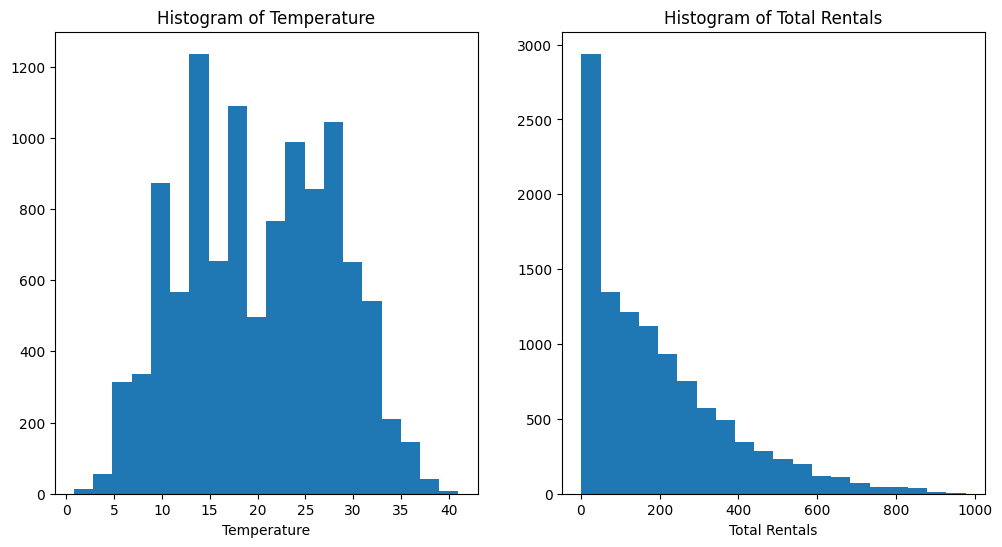

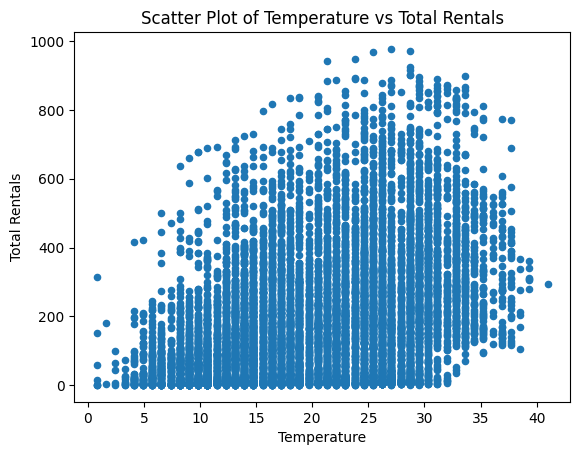

In [84]:
fig = plt.figure(figsize=(12, 6))

temp = fig.add_subplot(121)
count = fig.add_subplot(122)


temp.hist(df.temp, bins=20)
temp.set_xlabel('Temperature')
temp.set_title('Histogram of Temperature')

count.hist(df['count'], bins=20)
count.set_xlabel('Total Rentals')
count.set_title('Histogram of Total Rentals')

plt.show()

df.plot(kind='scatter', x='temp', y='count')
plt.title('Scatter Plot of Temperature vs Total Rentals')
plt.xlabel('Temperature')
plt.ylabel('Total Rentals')
plt.show()

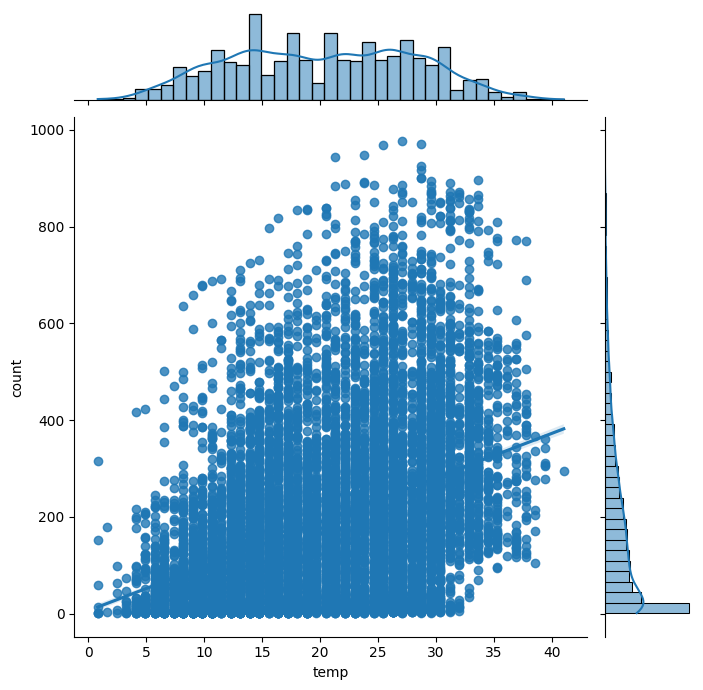

In [85]:
sns.jointplot(x="temp", y="count", data=df, kind = 'reg',fit_reg= True, height = 7)
plt.show()

Preparing and then Seperating the data in test and train data for OLS Model 2.

In [90]:
# Select temp, dinspeed, registered as the predictor variable (X)
x = df[['temp' , 'windspeed', 'registered']].values

# Dependent variable (y): count
y = df['count'].values

x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 1/3, random_state=5)



Summarizng the data using Regression OLS (Ordinary Least Squares) Model 2

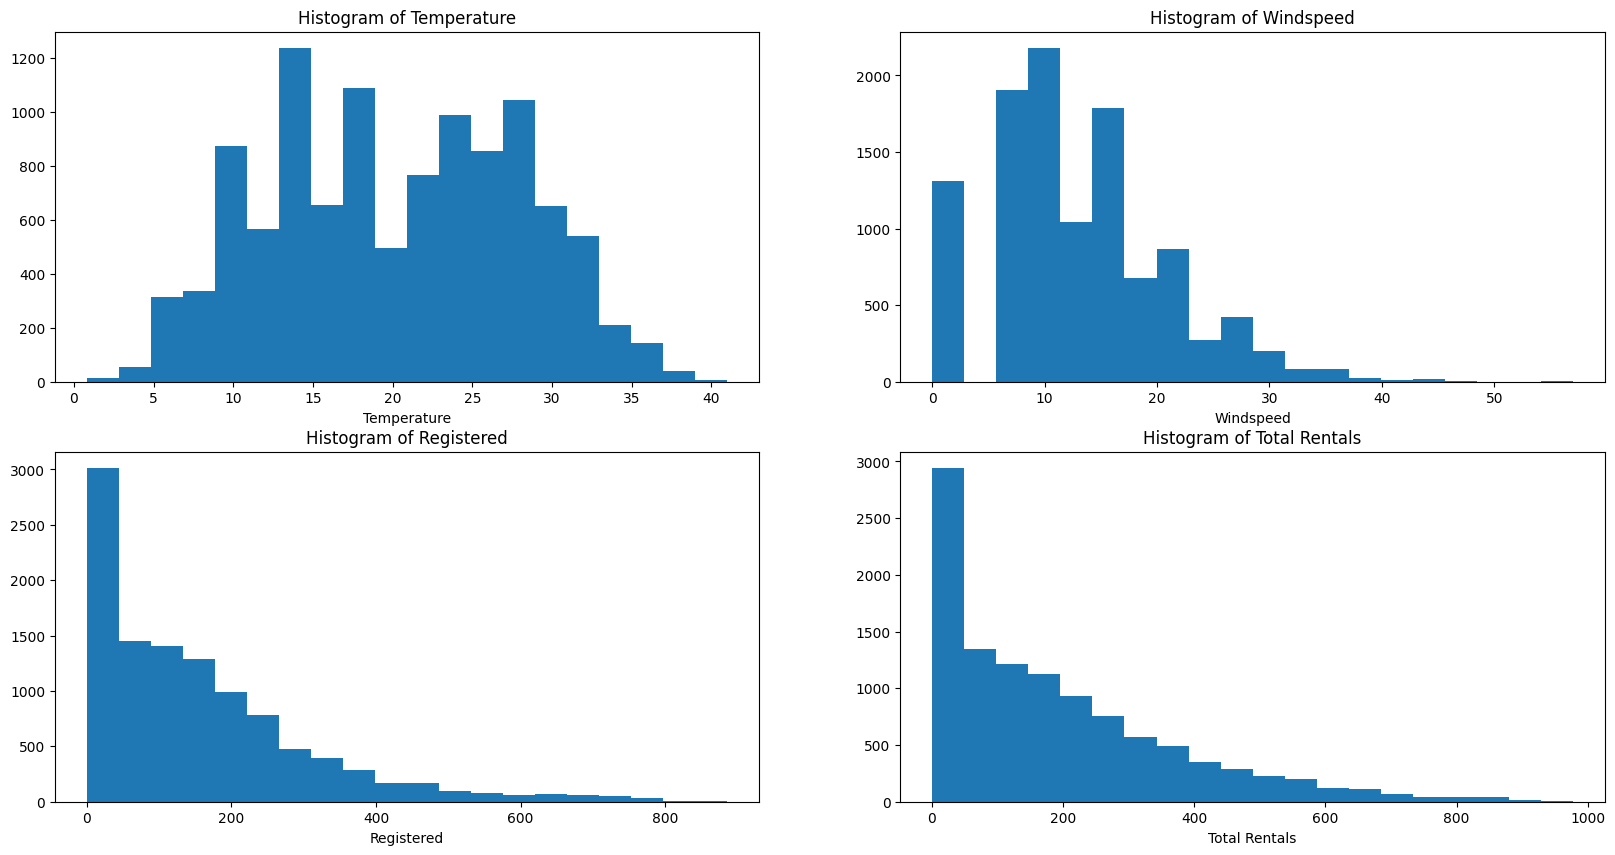

In [95]:

fig = plt.figure(figsize=(20, 10))

# plotting rows, columns, plot number
temp = fig.add_subplot(221)
windspeed = fig.add_subplot(222)
registered = fig.add_subplot(223)
count = fig.add_subplot(224)

temp.hist(df.temp, bins=20)
temp.set_xlabel('Temperature')
temp.set_title('Histogram of Temperature')

windspeed.hist(df.windspeed, bins=20)
windspeed.set_xlabel('Windspeed')
windspeed.set_title('Histogram of Windspeed')

registered.hist(df.registered, bins=20)
registered.set_xlabel('Registered')
registered.set_title('Histogram of Registered')

count.hist(df['count'], bins=20)
count.set_xlabel('Total Rentals')
count.set_title('Histogram of Total Rentals')

plt.show()



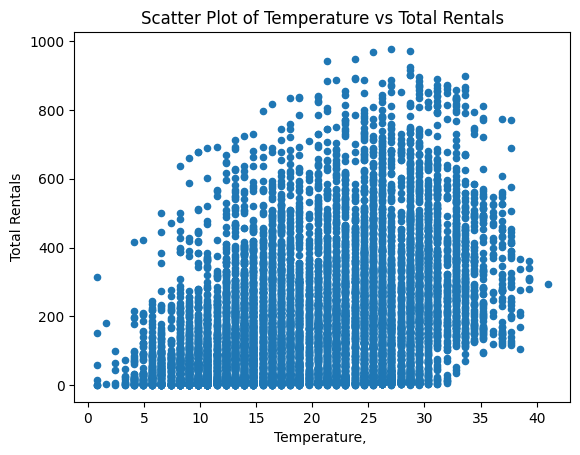

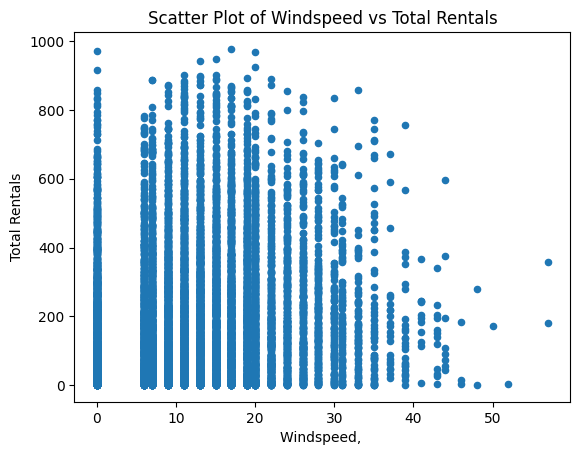

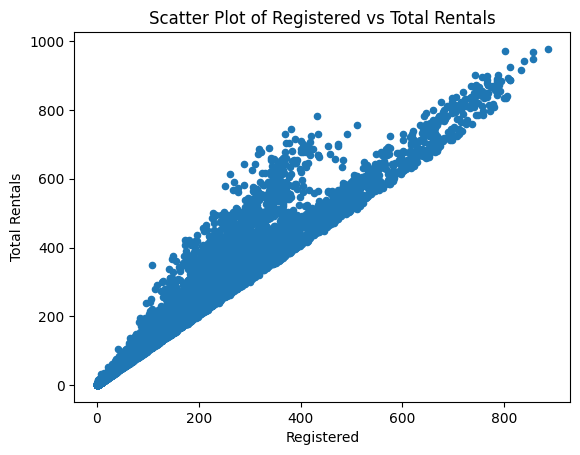

In [98]:
df.plot(kind='scatter', x='temp', y='count')
plt.title('Scatter Plot of Temperature vs Total Rentals')
plt.xlabel('Temperature, ')
plt.ylabel('Total Rentals')

df.plot(kind='scatter', x='windspeed', y='count')
plt.title('Scatter Plot of Windspeed vs Total Rentals')
plt.xlabel('Windspeed, ')
plt.ylabel('Total Rentals')

df.plot(kind='scatter', x='registered', y='count')
plt.title('Scatter Plot of Registered vs Total Rentals')
plt.xlabel('Registered')
plt.ylabel('Total Rentals')


plt.show()

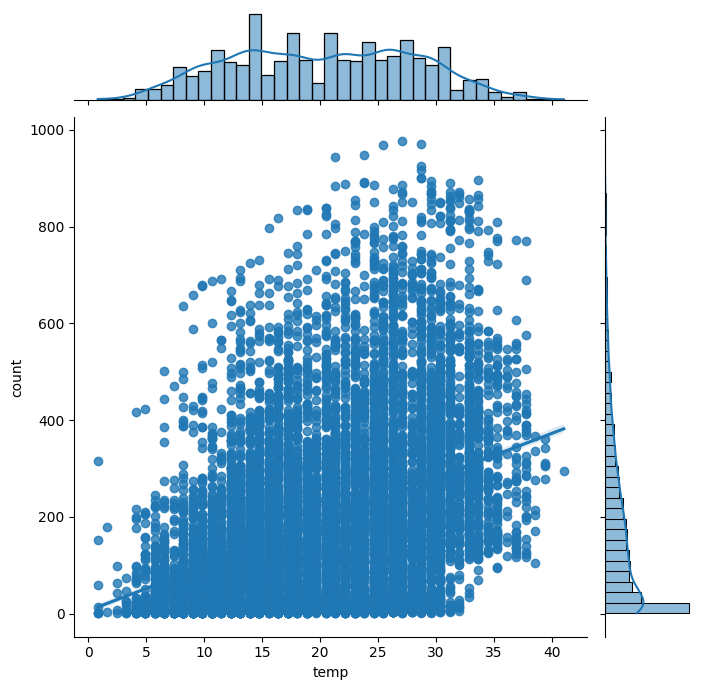

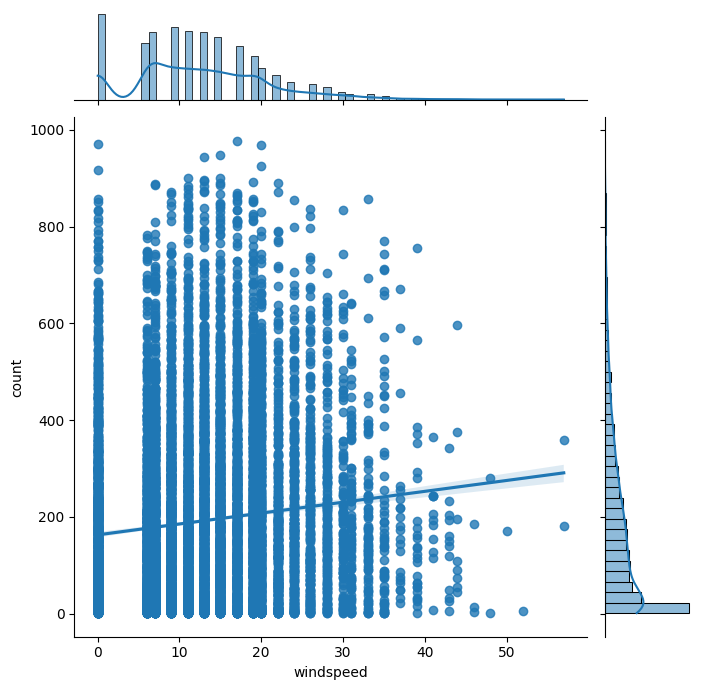

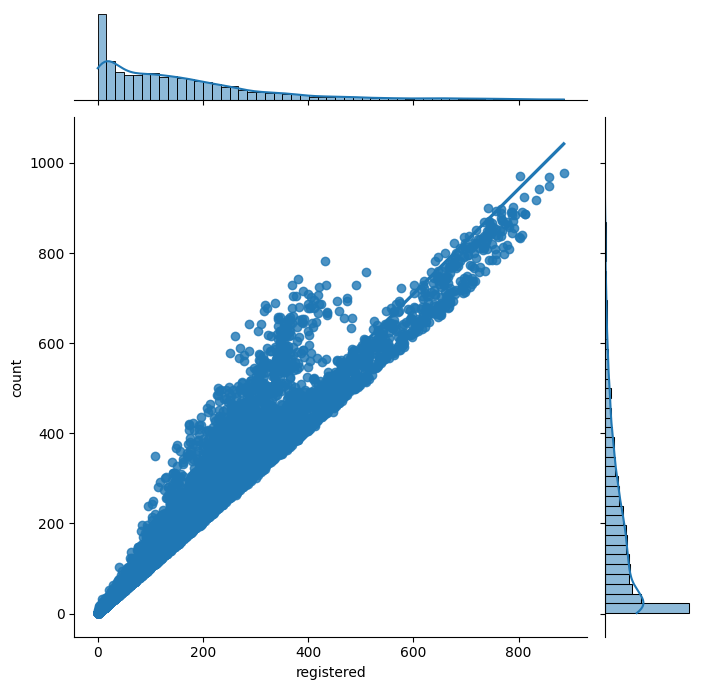

In [99]:
sns.jointplot(x="temp", y="count", data=df, kind = 'reg',fit_reg= True, height = 7)
plt.show()

sns.jointplot(x="windspeed", y="count", data=df, kind = 'reg',fit_reg= True, height = 7)
plt.show()

sns.jointplot(x="registered", y="count", data=df, kind = 'reg',fit_reg= True, height = 7)
plt.show()